# Line Radiative Transfer — Plane-Parallel Slab Example

This notebook walks through a complete Monte Carlo line radiative transfer calculation for a **plane-parallel slab** (the Neufeld problem). A slab of gas and dust is illuminated from one side. Photons scatter in a spectral line with **coherent frequency redistribution (CFR)** while dust continuously absorbs.

### Physics summary

1. Define the slab geometry and initial opacity
2. Generate source photons from the left face
3. Kratos MC transports photons through the slab
4. From the MC overlap-weighted excitation (`excitation_flux`), update excited-state populations
5. Compute new opacities from updated populations
6. Repeat until convergence

**No escape probability $\beta$ is used** — the MC iteration itself accounts for all optical depth effects.

Reference: Neufeld, D.A. 1990, ApJ, 350, 216

## 0. Setup — imports and constants

In [10]:
%matplotlib inline
import sys, os, shutil
sys.path.insert(0, os.path.expanduser('~/Seafile/seafile_sync/code/line_rt_pipeline'))

import numpy as np
import matplotlib.pyplot as plt

from core.source import make_cartesian_mesh
from core.fields import uniform_field, slice_plot_2d, write_kratos_fields, read_kratos_output
from core.iterator import iterate
from core.visualize import (
    plot_emergent_spectrum, plot_flux_slice,
    plot_population_map, plot_convergence,
)
from molecular.lamda_format import load_species_transition

# CGS constants
h  = 6.62607015e-27
c  = 2.99792458e10
kb = 1.380649e-16
mp = 1.67262192e-24
Lsun = 3.828e33
AU   = 1.49598e13

print('All imports successful.')

All imports successful.


## 1. Define the slab geometry

A Cartesian mesh: 64 cells along $x$ (the slab normal), 1 cell each in $y$ and $z$.
Physical thickness = 10 AU, centered at $x=0$.

In [11]:
mesh = make_cartesian_mesh(
    n_cell=(64, 2, 2),
    x_min=(-5, 0, 0),
    x_max=(5, 0.2, 0.2),
)
n_tot = mesh['n_tot']
dx_cm = mesh['dx'][0] * AU
slab_cm = 10.0 * AU

print(f'Mesh: {mesh["n_cell"]} cells')
print(f'Cell width: {dx_cm/AU:.3f} AU = {dx_cm:.2e} cm')
print(f'Slab thickness: {slab_cm/AU:.0f} AU')

Mesh: [64  2  2] cells
Cell width: 0.156 AU = 2.34e+12 cm
Slab thickness: 10 AU


## 2. Set physical parameters

The **line-center scattering optical depth** $\tau_0 = 100$ across the full slab.
The **absorption optical depth** $\tau_{\rm abs} = 1$.

These determine the **inverse mean free paths** (cm⁻¹):
$$ {\rm mfp\_i\_sca} = \tau_0 / L_{\rm slab}, \quad
   {\rm mfp\_i\_abs} = \tau_{\rm abs} / L_{\rm slab} $$

In [12]:
tau0_slab = 100.0    # line-center scattering optical depth
tau_abs   = 1.0      # absorption optical depth

mfp_i_sca = tau0_slab / slab_cm
mfp_i_abs = tau_abs  / slab_cm
b_param   = 1.0e5    # Doppler b = 1 km/s

print(f'mfp_i_sca = {mfp_i_sca:.3e} cm⁻¹  ({tau0_slab/mfp_i_sca/AU:.1f} AU path per τ=1)')
print(f'mfp_i_abs = {mfp_i_abs:.3e} cm⁻¹  ({tau_abs/mfp_i_abs/AU:.1f} AU path per τ=1)')

mfp_i_sca = 6.685e-13 cm⁻¹  (10.0 AU path per τ=1)
mfp_i_abs = 6.685e-15 cm⁻¹  (10.0 AU path per τ=1)


### Build the field arrays for Kratos

9 fields written to the binary file: `mfp_i_sca_0, mfp_i_abs_0, b_sca, b_abs, vel_0, vel_1, vel_2, temp, n_cell`.
All are uniform across the slab for this example.

In [13]:
fields = {
    'mfp_i_sca_0': uniform_field(mfp_i_sca, n_tot),
    'mfp_i_abs_0': uniform_field(mfp_i_abs, n_tot),
    'b_sca':       uniform_field(b_param,   n_tot),
    'b_abs':       uniform_field(b_param,   n_tot),
    'vel_0':       uniform_field(b_param,   n_tot),   # v_x = b (creates velocity gradient)
    'vel_1':       np.zeros(n_tot, dtype=np.float64),
    'vel_2':       np.zeros(n_tot, dtype=np.float64),
    'temp':         uniform_field(100.0, n_tot),
}
print(f'Built {len(fields)} field arrays, each {n_tot} cells')


Built 8 field arrays, each 256 cells


## 3. Generate source photons

A **point source** at $x=-4.5$ (just outside the left face) emits $5\times 10^4$ photon packets.
Wavelength $\lambda = 2.35$ µm (CO v=0→2 band head). Luminosity $L = 0.8\,L_\odot$.

### Unit chain (source → photon proper)

$$\text{Luminosity } L \;[\text{erg/s}] \;\longrightarrow\; \dot{N} = \frac{L}{h\nu} \;[\text{photons/s}] \;\longrightarrow\; w = \frac{\dot{N}}{N_{\rm MC}} \;[\text{per-packet weight}]$$

In [14]:
n_photon = 50000
L = 0.8 * Lsun
lam = 2.35e-4  # cm

E_ph = h * c / lam
Ndot = L / E_ph
proper = Ndot / n_photon

print(f'Photon energy E_ph = {E_ph:.2e} erg = {E_ph/1.602e-12:.2f} eV')
print(f'Photon rate Ndot = {Ndot:.2e} ph/s')
print(f'Proper weight  w = {proper:.2e} ph/packet')

ph_arr = np.zeros((n_photon, 11), dtype=np.float64)
ph_arr[:, 0] = -4.5   # x position
ph_arr[:, 1] =  0.1   # y position
ph_arr[:, 2] =  0.1   # z position
ph_arr[:, 3] =  1.0   # direction: all +x
ph_arr[:, 4] =  0.0
ph_arr[:, 5] =  0.0
ph_arr[:, 6] = proper # per-packet weight
ph_arr[:, 7] =  0.0   # velocity offset (line center)
sigma = b_param / np.sqrt(2)
amplitude = 1.0
ph_arr[:, 8] = sigma
ph_arr[:, 9] = amplitude
ph_arr[:, 10] = 0.0

print(f'Photon array: {ph_arr.shape[0]} packets, {ph_arr.shape[1]} columns')

Photon energy E_ph = 8.45e-13 erg = 0.53 eV
Photon rate Ndot = 3.62e+45 ph/s
Proper weight  w = 7.25e+40 ph/packet
Photon array: 50000 packets, 11 columns


## 4. Load molecular data

Load CO rotational level data from the embedded LAMDA database. This provides Einstein A coefficients,
level degeneracies, and energies needed for the population calculation.

In [15]:
lamda_path = os.path.join(os.path.expanduser('~/Seafile/seafile_sync/code/line_rt_pipeline'), 'molecular', 'embedded', 'co.dat')
co, tr = load_species_transition(lamda_path, freq_GHz=115.271202)
tr_idx = co.find_transition_idx(tr)
print(f'Species: {co.name}')
print(f'  Levels: {co.n_levels}')
print(f'  Transitions: {co.n_transitions}')
print(f'  Collision partners: {len(co.collision_partners)}')
print()
print(f'Selected: J={tr.upper}→{tr.lower}, A={tr.A_ul:.2e} s⁻¹, ν={tr.freq_GHz:.1f} GHz')
print()
print('All transitions:')
for i in range(min(5, co.n_transitions)):
    u, l = int(co.transitions[i, 0]), int(co.transitions[i, 1])
    A = co.get_Einstein_A(u, l)
    nu = co.get_nu(u, l)
    print(f'  J={u} -> J={l}:  A = {A:.2e} s⁻¹,  ν = {nu:.1f} GHz')
sigma_co = co.cross_section(0, b_param)
n_species = (tau0_slab / slab_cm) / sigma_co
print(f"  n_species (from τ₀={tau0_slab:.0f}): {n_species:.2e} cm⁻³")


Species: CO
  Levels: 10
  Transitions: 9
  Collision partners: 0

First 5 transitions:
  J=1 -> J=0:  A = 7.20e-08 s⁻¹,  ν = 115.3 GHz
  J=2 -> J=1:  A = 2.14e-07 s⁻¹,  ν = 230.5 GHz
  J=3 -> J=2:  A = 4.28e-07 s⁻¹,  ν = 345.8 GHz
  J=4 -> J=3:  A = 7.19e-07 s⁻¹,  ν = 461.0 GHz
  J=5 -> J=4:  A = 1.10e-06 s⁻¹,  ν = 576.3 GHz
  n_species (from τ₀=100): 1.87e+12 cm⁻³


## 5. Run MC iteration

Three cycles of MC transport → population update → opacity update.

Each cycle runs Kratos with the current fields, reads back `excitation_flux` (overlap-weighted excitation),
computes updated populations, regenerates fields for the next cycle.

This cell will take **~15–20 seconds** (3 cycles × ~5s each for 50k photons).

In [18]:
results, final_pops = iterate(
    ph_arr, co, fields, mesh,
    n_cycles=3,
    n_photon=n_photon,
    n_step=10000,
    n_scat=100000,
    ph_mode=1,
    transition_idx=tr_idx, mol_mass=28.0,
    n_species=n_species,
    work_dir='/tmp/line_rt_notebook',
    unit_l0=1.49598e13, unit_t0=1.0,
    par_overrides={'kinds': 'fre fre per per per per'},
)

print(f'\nCompleted {len(results)} cycles.')
for k, r in enumerate(results):
    print(f'  Cycle {k}:  excitation_flux_max={r.get("excitation_flux", np.zeros(1)).max():.4f},  flx_max={r.get("flx", np.zeros(1)).max():.4f},  '
          f'escaped={len(r.get("photons",{}).get("vel",[]))} photons')

Wrote fields: /tmp/line_rt_notebook/fields_cycle0.bin
Wrote photons: /tmp/line_rt_notebook/photons_cycle0.bin (50000 photons, 8 cols)
Wrote par file: /tmp/line_rt_notebook/cycle0.par
[cycle 0] Done in 1s, bin=cycle0_00000.bin
Wrote fields: /tmp/line_rt_notebook/fields_cycle1.bin
Wrote photons: /tmp/line_rt_notebook/photons_cycle1.bin (50000 photons, 8 cols)
Wrote par file: /tmp/line_rt_notebook/cycle1.par
[cycle 1] Done in 1s, bin=cycle1_00000.bin
Wrote fields: /tmp/line_rt_notebook/fields_cycle2.bin
Wrote photons: /tmp/line_rt_notebook/photons_cycle2.bin (50000 photons, 8 cols)
Wrote par file: /tmp/line_rt_notebook/cycle2.par
[cycle 2] Done in 1s, bin=cycle2_00000.bin

Completed 3 cycles.
  Cycle 0:  excitation_flux_max=4116293.0000,  flx_max=986567.7500,  escaped=50000 photons
  Cycle 1:  excitation_flux_max=4122238.2500,  flx_max=987775.0625,  escaped=50000 photons
  Cycle 2:  excitation_flux_max=4123649.2500,  flx_max=987811.2500,  escaped=50000 photons


## 6. Plots — Emergent Spectrum

The **emergent spectrum** is a histogram of escaped photon velocities weighted by their proper weights.
Velocity is relative to line center ($v=0$). The shape is characteristic of the **Neufeld CFR** solution:
a double-peaked profile with a dip at line center due to absorption.

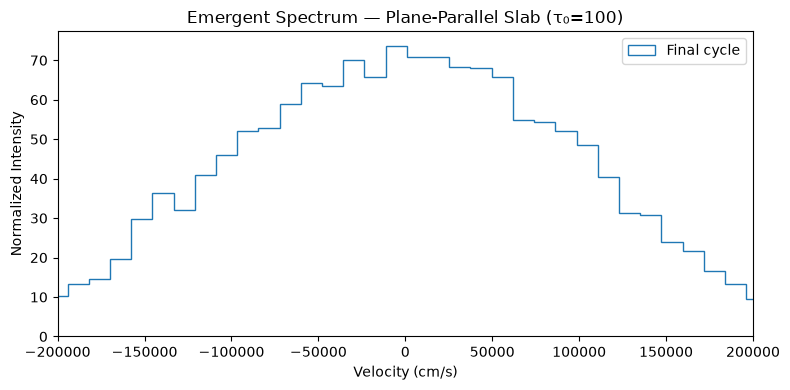

In [19]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_emergent_spectrum(ax, results[-1].get('photons', {}), bins=60,
                       xlim=(-2e5, 2e5), label='Final cycle')
ax.set_xlabel('Velocity (cm/s)')
ax.set_ylabel('Normalized Intensity')
ax.set_title('Emergent Spectrum — Plane-Parallel Slab (τ₀=100)')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Plots — Spatial Flux

The **flux map** shows where radiation intensity is highest inside the slab.
In a plane-parallel slab, flux decays exponentially from the illuminated face.

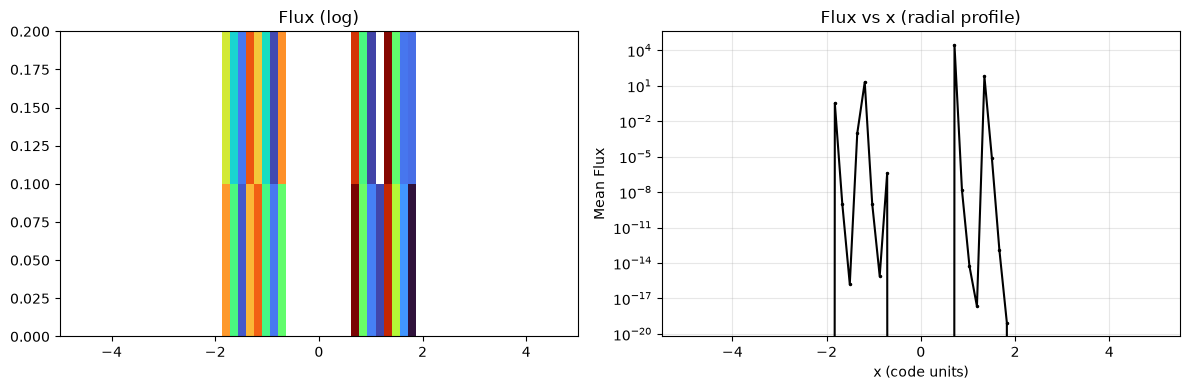

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

plot_flux_slice(ax1, results[-1]['flx'], mesh, title='Flux (log)', log=True)

# Radial profile: mean flux vs x
x_cells = np.linspace(mesh['x_min'][0], mesh['x_min'][0] + mesh['dx'][0] * mesh['n_cell'][0], mesh['n_cell'][0])
flx_1d = results[-1]['flx'].reshape(*mesh['n_cell'], -1)[:, 0, 0, 0].copy()
ax2.semilogy(x_cells, flx_1d, 'k.-', markersize=3)
ax2.set_xlabel('x (code units)')
ax2.set_ylabel('Mean Flux')
ax2.set_title('Flux vs x (radial profile)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Plots — Population Convergence

The excited-state fraction shows where the gas has been pumped by the radiation field.
Lower state is depleted, upper state is populated — this feedback modifies the opacity for the next cycle.

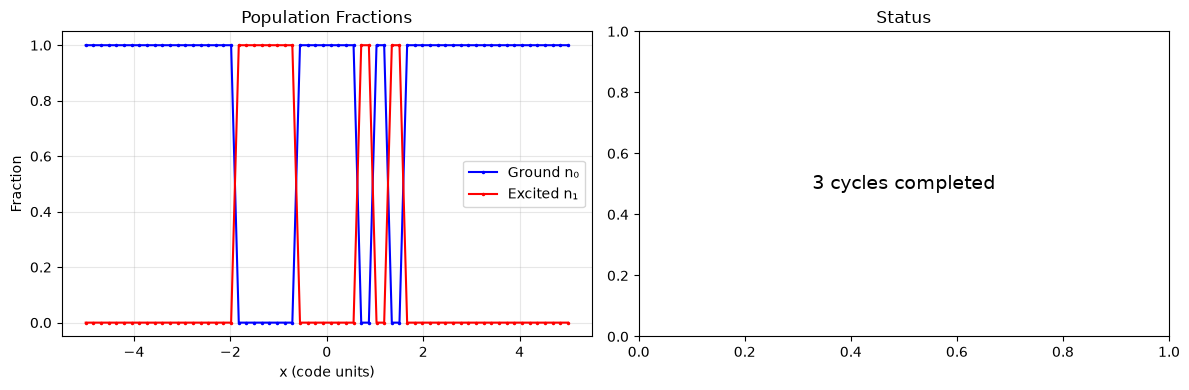

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Population vs x for the 1D slab
if len(final_pops) >= 2:
    pop_vals = list(final_pops.values())
    pop_2d = np.stack([pop_vals[0], pop_vals[1]], axis=0).reshape(2, *mesh['n_cell'])
    n0 = pop_2d[0, :, 0, 0]   # ground state along x
    n1 = pop_2d[1, :, 0, 0]   # excited state along x
    n_tot_1d = n0 + n1
    
    ax1.plot(x_cells, n0 / n_tot_1d, 'b.-', label='Ground n₀', markersize=3)
    ax1.plot(x_cells, n1 / n_tot_1d, 'r.-', label='Excited n₁', markersize=3)
    ax1.set_xlabel('x (code units)')
    ax1.set_ylabel('Fraction')
    ax1.set_title('Population Fractions')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

ax2.text(0.5, 0.5, f'{len(results)} cycles completed',
         transform=ax2.transAxes, ha='center', va='center', fontsize=14)
ax2.set_title('Status')

plt.tight_layout()
plt.show()

## 9. Cleanup

Remove temporary working directories.

In [11]:
for d in ['/tmp/line_rt_notebook']:
    if os.path.exists(d):
        shutil.rmtree(d)
print('Temporary files cleaned up.')

Temporary files cleaned up.


---

### What next?

- **Change tau0_slab**: try τ₀ = 10, 100, 1000 to see how the emergent spectrum changes
- **Change vel_width**: the Doppler width affects the scattering cross-section
- **Try a point source in the center**: illuminating from the middle changes the spatial pattern
- **Add an analytic field gradient**: n(r) = n₀ (r/r₀)⁻² to simulate a wind
- **Use the interactive notebook**: open `ui/notebook.ipynb` for sliders and live plots

See `docs/PHYSICS.md` for the full physics tutorial.